In [1]:
pip install numpy

In [2]:
pip install pandas

In [3]:
pip install pandas mplfinance yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.0 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import mplfinance as mpf
import yfinance as yf
from google.colab import drive as dr
dr.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_dat = pd.read_csv('drive/My Drive/Internship/Summer - 2026/final_data.csv', index_col=0) #Change the location of the file if you want to run in your device
train_dat

,datetime,open,high,low,close,volume,ATR,trade_type,signals
Unnamed: 0,,,,,,,,,
0,2019-09-08,10000.00,10412.65,10000.00,10391.63,3096.291,NaN,HOLD,0
1,2019-09-09,10316.62,10475.54,10077.22,10307.00,14824.373,NaN,HOLD,0
2,2019-09-10,10307.00,10382.97,9940.87,10102.02,9068.955,NaN,HOLD,0
3,2019-09-11,10094.27,10293.11,9884.31,10159.55,10897.922,NaN,HOLD,0
4,2019-09-12,10163.06,10450.13,10042.12,10415.13,15609.634,NaN,HOLD,0
...,...,...,...,...,...,...,...,...,...
1572,2023-12-28,43453.80,43850.00,42320.50,42600.10,257515.182,1514.542639,HOLD,0
1573,2023-12-29,42600.10,43171.90,41283.20,42095.10,337421.865,1541.268165,SHORT,-1
1574,2023-12-30,42095.10,42654.60,41550.00,42174.20,183890.670,1510.077582,HOLD,0


In [6]:
train_dat.index = pd.to_datetime(train_dat['datetime'])

In [7]:
train_dat.columns.tolist()

['datetime',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'ATR',
 'trade_type',
 'signals']

In [8]:
#train_dat.drop('Unnamed: 0', axis=1)

In [9]:
'''dummy_data = yf.download("AAPL", start="2026-01-01", end="2026-06-01")
dummy_data[0:10]'''

'dummy_data = yf.download("AAPL", start="2026-01-01", end="2026-06-01")\ndummy_data[0:10]'

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


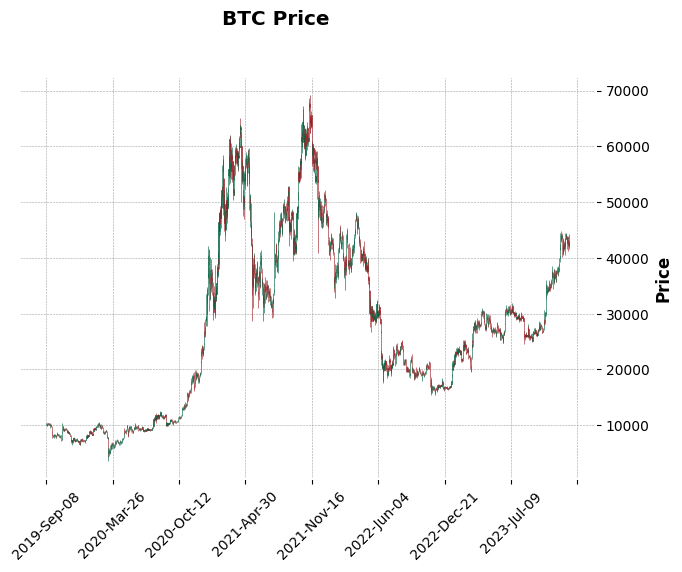

In [10]:
mpf.plot(train_dat, type='candle', style='charles', title='BTC Price', ylabel='Price')

In [11]:
len(train_dat), train_dat['close'][0:10]

(1577,
 datetime
 2019-09-08    10391.63
 2019-09-09    10307.00
 2019-09-10    10102.02
 2019-09-11    10159.55
 2019-09-12    10415.13
 2019-09-13    10341.34
 2019-09-14    10332.25
 2019-09-15    10302.22
 2019-09-16    10249.27
 2019-09-17    10186.52
 Name: close, dtype: float64)

In [12]:
#Strategy: Use long-SMA and short-SMA

In [13]:
'''Questions:
1) Compare SMA, WMA and EMA (if possible)?
2) Compare Standard 50/200 window and 10/50 window performance (data shortage)?'''

'Questions:\n1) Compare SMA, WMA and EMA (if possible)?\n2) Compare Standard 50/200 window and 10/50 window performance (data shortage)?'

In [14]:
def SMA(x, y, dat): #Here, x is size of moving windows (MWs) of fast and y is size of MWs of slow => x<y
  ls_f = []  #creates a list for Fast SMA
  ls_s = []  #creates a list for Slow SMA
  for i in range(len(dat)+1): #Fast SMA
    z1 = 0
    z2 = 0
    '''if i>=x:
    else: pass'''

    if i>=y:
      for j in range(x):
        z1 = z1 + dat[i-j-1]
      ls_f.append(z1/x)

      for j in range(y):
        z2 = z2 + dat[i-j-1]
      ls_s.append(z2/y)
    else: pass

  return ls_f, ls_s

In [15]:
train_cl = train_dat['close'].to_numpy()
train_cl[0:10]

array([10391.63, 10307.  , 10102.02, 10159.55, 10415.13, 10341.34,
       10332.25, 10302.22, 10249.27, 10186.52])

In [16]:
SMA_cl_f, SMA_cl_s = SMA(5, 20, train_cl)
SMA_cl_f[0:5], SMA_cl_s[0:5]

([np.float64(8602.862),
  np.float64(8301.545999999998),
  np.float64(8180.816000000001),
  np.float64(8151.969999999999),
  np.float64(8197.939999999999)],
 [np.float64(9818.721),
  np.float64(9708.9085),
  np.float64(9595.656500000001),
  np.float64(9504.8475),
  np.float64(9411.369999999999)])

In [17]:
len(SMA_cl_f), len(SMA_cl_s)

(1558, 1558)

In [18]:
'''for i in range(len(SMA_cl_f)-len(SMA_cl_s)):
  SMA_cl_f.remove(SMA_cl_f[0])
len(SMA_cl_f)'''

'for i in range(len(SMA_cl_f)-len(SMA_cl_s)):\n  SMA_cl_f.remove(SMA_cl_f[0])\nlen(SMA_cl_f)'

In [19]:
diff_5_20 = []
for i in range(len(SMA_cl_f)):
  diff_5_20.append(SMA_cl_f[i]-SMA_cl_s[i])

In [20]:
diff_5_20[0:10], len(diff_5_20)

([np.float64(-1215.8590000000004),
  np.float64(-1407.362500000001),
  np.float64(-1414.8405000000002),
  np.float64(-1352.8775000000005),
  np.float64(-1213.4300000000003),
  np.float64(-1075.1564999999991),
  np.float64(-964.125),
  np.float64(-836.3205000000016),
  np.float64(-760.0564999999988),
  np.float64(-727.6744999999992)],
 1558)

In [21]:
sign_5_20 = []
b = 'LONG'
s = 'SHORT'
for i in range(len(diff_5_20)):
  if diff_5_20[i]<0:
    sign_5_20.append(s)
  else:
    sign_5_20.append(b)

In [22]:
sign_5_20[10:30], len(sign_5_20)

(['SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT'],
 1558)

In [23]:
#train_dat['Strat_5_20_SMA'] = [np.nan]*(len(train_dat)-len(sign_5_20)) + sign_5_20

In [25]:
#train_dat, train_dat['Strat_5_20_SMA'][18:23], train_dat['close'][20], 20/train_dat['close'][20]

In [ ]:
#Compute PnL

In [26]:
def PnL(train_dat, strat):
  Ui = 1000 #USD initial margin at hand
  U = 1000
  B = 0    #Yet to get into trade so no BTC at hand
  br_fee = 1.5 #Brokerage fee in percentage
  state = 'SHORT'
  trade_budget = 0
  Profit = 0

  for i in range(len(train_dat)-len(strat), len(train_dat)):
    if i==len(train_dat)-1:
      if state == 'SHORT':
        if strat[i]=='LONG': #Signals to sell a BTC when we hold in BTC
          U = U #Shouldn't buy BTC on last to have all the wealth in USD
      elif state == 'LONG':   #If holding BTC on last day
        trade_budget = B
        U = trade_budget*train_dat['close'].iloc[i]
        U = U - br_fee*U/100
      #else: pass

    else:
      if state == 'SHORT':
        if strat[i]=='LONG': #Signals to purchase a BTC when we hold in USD
          trade_budget = U - br_fee*U/100
          B = trade_budget/train_dat['close'].iloc[i]
          state = 'LONG'
        else: pass

      elif state == 'LONG':
        if strat[i]=='SHORT': #Signals to sell a BTC when we hold in BTC
          trade_budget = B
          U = trade_budget*train_dat['close'].iloc[i]
          U = U - br_fee*U/100
        else: pass

  Profit = (U-Ui)*100/Ui
  #print("Total wealth at hand when 1000 USD was given to us", U, "\n And profit made", PnL, "%")
  return Profit

In [27]:
#len(train_dat), len(train_dat['Strat_5_20_SMA'])

In [28]:
sign_5_20 = [np.nan]*(len(train_dat)-len(sign_5_20)) + sign_5_20
len(sign_5_20)

1577

In [29]:
#SMA 5/20 Window's profit
print("The Total profit of trading using SMA 5/20 is", PnL(train_dat, sign_5_20), "%")

The Total profit of trading using SMA 5/20 is 417.0133538026703 %


In [30]:
#Try the standard 50/200 in SMA?

In [31]:
SMA_cl_f_50, SMA_cl_s_200 = SMA(50, 200, train_cl)
SMA_cl_f_50[0:5], SMA_cl_s_200[0:5], len(SMA_cl_f_50), len(SMA_cl_s_200)

([np.float64(8341.713600000001),
  np.float64(8283.7888),
  np.float64(8215.299200000001),
  np.float64(8143.4878),
  np.float64(8062.884600000001)],
 [np.float64(8345.028099999998),
  np.float64(8326.738749999999),
  np.float64(8306.97195),
  np.float64(8287.616599999998),
  np.float64(8266.2002)],
 1378,
 1378)

In [32]:
diff_50_200 = []
for i in range(len(SMA_cl_f_50)):
  diff_50_200.append(SMA_cl_f_50[i]-SMA_cl_s_200[i])
diff_50_200[0:10], len(diff_50_200)

([np.float64(-3.3144999999967695),
  np.float64(-42.94994999999835),
  np.float64(-91.6727499999979),
  np.float64(-144.12879999999768),
  np.float64(-203.31559999999808),
  np.float64(-258.721349999998),
  np.float64(-308.2193499999985),
  np.float64(-361.51664999999775),
  np.float64(-414.93089999999756),
  np.float64(-467.5301499999978)],
 1378)

In [33]:
sign_50_200 = []
b = 'LONG'
s = 'SHORT'
for i in range(len(diff_50_200)):
  if diff_50_200[i]<0:
    sign_50_200.append(s)
  else:
    sign_50_200.append(b)
sign_50_200[50:70], len(sign_50_200)

(['SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG'],
 1378)

In [34]:
sign_50_200 = [np.nan]*(len(train_dat)-len(sign_50_200)) + sign_50_200
len(sign_50_200)

1577

In [35]:
#SMA 50/200 Window's profit
print("The Total profit of trading using SMA 50/200 is", PnL(train_dat, sign_50_200), "%")

The Total profit of trading using SMA 50/200 is 373.656134602649 %


In [36]:
'''Shorter windows like 5/20 does better than longer windows like 50/200'''

'Shorter windows like 5/20 does better than longer windows like 50/200'

In [37]:
#Try 5/20 in WMA?

In [38]:
def WMA(x, y, dat): #Here, x is size of moving windows (MWs) of fast and y is size of MWs of slow => x<y
  ls_f = []  #creates a list for Fast WMA
  ls_s = []  #creates a list for Slow WMA
  for i in range(len(dat)+1):
    z1 = 0
    z2 = 0
    '''if i>=x:
    else: pass'''

    if i>=y:
      for j in range(x):
        z1 = z1 + (x-j)*dat[i-j-1]
      ls_f.append(2*z1/(x*(x+1)))

      for j in range(y):
        z2 = z2 + (y-j)*dat[i-j-1]
      ls_s.append(2*z2/(y*(y+1)))
    else: pass

  return ls_f, ls_s

In [39]:
WMA_cl_f_5, WMA_cl_s_20 = WMA(5, 20, train_cl)
WMA_cl_f_5[0:5], WMA_cl_s_20[0:5], len(WMA_cl_f_5), len(WMA_cl_s_20)

([np.float64(8360.439333333334),
  np.float64(8224.612),
  np.float64(8138.083333333333),
  np.float64(8173.091333333333),
  np.float64(8219.101333333334)],
 [np.float64(9487.962333333333),
  np.float64(9333.358428571428),
  np.float64(9174.601428571428),
  np.float64(9049.857),
  np.float64(8934.157238095237)],
 1558,
 1558)

In [40]:
diff_WMA_5_20 = []
for i in range(len(WMA_cl_f_5)):
  diff_WMA_5_20.append(WMA_cl_f_5[i]-WMA_cl_s_20[i])
diff_WMA_5_20[0:10], len(diff_WMA_5_20)

([np.float64(-1127.5229999999992),
  np.float64(-1108.7464285714286),
  np.float64(-1036.5180952380952),
  np.float64(-876.7656666666671),
  np.float64(-715.0559047619026),
  np.float64(-562.7768571428569),
  np.float64(-463.42719047618993),
  np.float64(-397.19671428571564),
  np.float64(-349.36190476190404),
  np.float64(-365.1260476190455)],
 1558)

In [41]:
sign_WMA_5_20 = []
b = 'LONG'
s = 'SHORT'
for i in range(len(diff_WMA_5_20)):
  if diff_WMA_5_20[i]<0:
    sign_WMA_5_20.append(s)
  else:
    sign_WMA_5_20.append(b)
sign_WMA_5_20[10:30], len(sign_WMA_5_20)

(['SHORT',
  'SHORT',
  'SHORT',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'LONG',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'LONG'],
 1558)

In [42]:
sign_WMA_5_20 = [np.nan]*(len(train_dat)-len(sign_WMA_5_20)) + sign_WMA_5_20
len(sign_WMA_5_20)

1577

In [43]:
#WMA 5/20 Window's profit
print("The Total profit of trading using WMA 5/20 is", PnL(train_dat, sign_WMA_5_20), "%")

The Total profit of trading using WMA 5/20 is 401.5561650744154 %


In [44]:
#Try implementing EMA

In [45]:
def EMA(x, y, dat): #Here, x is size of moving windows (MWs) of fast and y is size of MWs of slow => x<y
  ls_f = []  #creates a list for Fast SMA
  ls_s = []  #creates a list for Slow SMA
  x_alpha = 2/(x+1)
  y_alpha = 2/(y+1)
  for i in range(len(dat)+1): #Fast SMA
    z1 = 0
    z2 = 0
    '''if i>=x:
    else: pass'''

    if i==y:
      for j in range(x):
        z1 = z1 + (x-j)*dat[i-j-1]
      ls_f.append(2*z1/(x*(x+1)))

      for j in range(y):
        z2 = z2 + (y-j)*dat[i-j-1]
      ls_s.append(2*z2/(y*(y+1)))

    elif i>y:
      z1 = x_alpha*dat[i-1] + (1-x_alpha)*ls_f[-1]
      ls_f.append(z1)
      z2 = y_alpha*dat[i-1] + (1-y_alpha)*ls_s[-1]
      ls_s.append(z2)

    else: pass

  return ls_f, ls_s

In [46]:
EMA_cl_f_5, EMA_cl_s_20 = EMA(5, 20, train_cl)
EMA_cl_f_5[0:5], EMA_cl_s_20[0:5], len(EMA_cl_f_5), len(EMA_cl_s_20)

([np.float64(8360.439333333334),
  np.float64(8305.419555555556),
  np.float64(8217.599703703705),
  np.float64(8240.346469135804),
  np.float64(8256.897646090536)],
 [np.float64(9487.962333333333),
  np.float64(9364.859253968254),
  np.float64(9238.86884882842),
  np.float64(9148.104196559047),
  np.float64(9066.379987362947)],
 1558,
 1558)

In [47]:
diff_EMA_5_20 = []
for i in range(len(EMA_cl_f_5)):
  diff_EMA_5_20.append(EMA_cl_f_5[i]-EMA_cl_s_20[i])
diff_EMA_5_20[0:10], len(diff_EMA_5_20)

([np.float64(-1127.5229999999992),
  np.float64(-1059.439698412698),
  np.float64(-1021.2691451247156),
  np.float64(-907.7577274232426),
  np.float64(-809.4823412724108),
  np.float64(-709.712034029928),
  np.float64(-658.4001968350985),
  np.float64(-627.9081300561502),
  np.float64(-591.5872602511927),
  np.float64(-615.0298384561002)],
 1558)

In [48]:
sign_EMA_5_20 = []
b = 'LONG'
s = 'SHORT'
for i in range(len(diff_EMA_5_20)):
  if diff_EMA_5_20[i]<0:
    sign_EMA_5_20.append(s)
  else:
    sign_EMA_5_20.append(b)
sign_EMA_5_20[10:30], len(sign_EMA_5_20)

(['SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'SHORT',
  'LONG'],
 1558)

In [49]:
sign_EMA_5_20 = [np.nan]*(len(train_dat)-len(sign_EMA_5_20)) + sign_EMA_5_20
len(sign_EMA_5_20)

1577

In [50]:
#EMA 5/20 Window's profit
print("The Total profit of trading using EMA 5/20 is", PnL(train_dat, sign_EMA_5_20), "%")

The Total profit of trading using EMA 5/20 is 364.8204418330586 %


In [51]:
'''Performance is SMA>WMA>EMA, Whipsaw effect??'''

'Performance is SMA>WMA>EMA, Whipsaw effect??'